# Condensed Matter: TFIM Hamiltonian Parameter Inference

Infer the transverse field of a finite transverse-field Ising model from sparse ground-state observables. The solver layer uses general trainable quantum-kernel regression and quantum Gaussian-process regression APIs.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Estimate an unknown Hamiltonian parameter from measured observables of a small quantum spin system.

**Explicit variables.** `h_values` are transverse-field strengths, `features` are noisy observables, and `h_pred` values are held-out field estimates.

**Quantum advantage context.** Quantum kernels can represent nonlinear similarity between correlated observables. This notebook is a correctness and workflow example, not a quantum-advantage claim.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

The notebook performs exact diagonalization for a four-site TFIM and extracts noisy ground-state observables. This physics code intentionally stays in the notebook.

In [2]:
def kron_all(ops):
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out

I = np.eye(2)
X = np.array([[0.0, 1.0], [1.0, 0.0]])
Z = np.array([[1.0, 0.0], [0.0, -1.0]])

def op_on(n_sites, site, op):
    ops = [I] * n_sites
    ops[site] = op
    return kron_all(ops)

def two_site_op(n_sites, i, j, op_i, op_j):
    ops = [I] * n_sites
    ops[i] = op_i
    ops[j] = op_j
    return kron_all(ops)

def tfim_ground_observables(h_values, *, n_sites=4, j_coupling=1.0, noise=0.01, seed=301):
    rng = np.random.default_rng(seed)
    z_ops = [op_on(n_sites, i, Z) for i in range(n_sites)]
    x_ops = [op_on(n_sites, i, X) for i in range(n_sites)]
    zz_ops = [two_site_op(n_sites, i, (i + 1) % n_sites, Z, Z) for i in range(n_sites)]

    features = []
    for h in h_values:
        hamiltonian = np.zeros((2**n_sites, 2**n_sites))
        for zz in zz_ops:
            hamiltonian -= j_coupling * zz
        for xop in x_ops:
            hamiltonian -= h * xop
        eigvals, eigvecs = np.linalg.eigh(hamiltonian)
        psi = eigvecs[:, np.argmin(eigvals)]
        mag_z = np.mean([np.vdot(psi, z @ psi).real for z in z_ops])
        mag_x = np.mean([np.vdot(psi, x @ psi).real for x in x_ops])
        corr_zz = np.mean([np.vdot(psi, zz @ psi).real for zz in zz_ops])
        energy_density = eigvals.min() / n_sites
        row = np.asarray([mag_z, mag_x, corr_zz, energy_density], dtype=float)
        row += rng.normal(0.0, noise, size=row.shape)
        features.append(row)
    return np.asarray(features, dtype=float)

rng = np.random.default_rng(301)
n_samples = 24
h_values = np.linspace(0.35, 1.85, n_samples)
rng.shuffle(h_values)
features = tfim_ground_observables(h_values, noise=0.008, seed=301)

x_train, x_test, h_train, h_test = train_test_split(
    features, h_values, test_size=0.3, random_state=301
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(h_train.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(h_test.reshape(-1, 1)).ravel()

print_section(
    "Dataset",
    [
        ("Problem", "TFIM transverse-field inference"),
        ("Samples", n_samples),
        ("Features", ["<Z>", "<X>", "<ZZ>", "E0/N"]),
        ("Target", "transverse field h"),
    ],
)


Dataset
+----------+---------------------------------+
| Metric   | Value                           |
+----------+---------------------------------+
| Problem  | TFIM transverse-field inference |
| Samples  | 24                              |
| Features | [<Z>, <X>, <ZZ>, E0/N]          |
| Target   | transverse field h              |
+----------+---------------------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

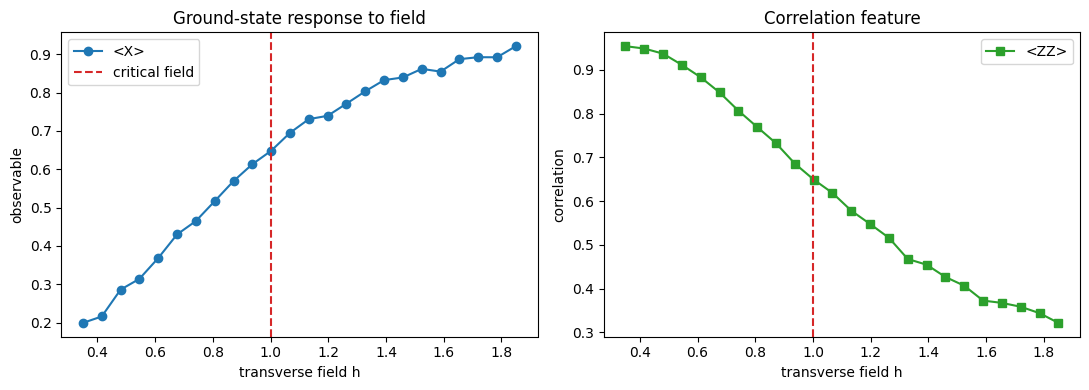

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = np.argsort(h_values)
axes[0].plot(h_values[order], features[order, 1], "o-", label="<X>")
axes[0].axvline(1.0, linestyle="--", color="tab:red", label="critical field")
axes[0].set_title("Ground-state response to field")
axes[0].set_xlabel("transverse field h")
axes[0].set_ylabel("observable")
axes[0].legend()
axes[1].plot(h_values[order], features[order, 2], "s-", color="tab:green", label="<ZZ>")
axes[1].axvline(1.0, linestyle="--", color="tab:red")
axes[1].set_title("Correlation feature")
axes[1].set_xlabel("transverse field h")
axes[1].set_ylabel("correlation")
axes[1].legend()
plt.tight_layout()
plt.show()


## Package-client quantum inverse models

The package supplies the QML implementations; the notebook supplies only the physics dataset.

In [4]:
tqk = TrainableQuantumKernelRegressor(
    embedding="data_reupload",
    embedding_layers=1,
    steps=2,
    step_size=0.04,
    alpha=1e-3,
    seed=301,
)
tqk.fit(x_train, y_train)
tqk_h_pred = y_scaler.inverse_transform(tqk.predict(x_test).reshape(-1, 1)).ravel()

gpr = QuantumGaussianProcessRegressor(QuantumKernel(embedding="zz", seed=302), alpha=1e-3)
gpr.fit(x_train, y_train)
gpr_scaled_pred, gpr_scaled_std = gpr.predict(x_test, return_std=True)
gpr_h_pred = y_scaler.inverse_transform(gpr_scaled_pred.reshape(-1, 1)).ravel()
gpr_h_std = gpr_scaled_std * float(y_scaler.scale_[0])

ridge = Ridge(alpha=1e-2)
ridge.fit(x_train, y_train)
ridge_h_pred = y_scaler.inverse_transform(ridge.predict(x_test).reshape(-1, 1)).ravel()

results = {
    "trainable_kernel_h_mae": mean_absolute_error(h_test, tqk_h_pred),
    "quantum_gpr_h_mae": mean_absolute_error(h_test, gpr_h_pred),
    "ridge_h_mae": mean_absolute_error(h_test, ridge_h_pred),
    "trainable_kernel_alignment": float(tqk.alignment_),
    "trainable_kernel_loss_final": float(tqk.loss_trace_[-1]),
}

print_section(
    "Results",
    [
        ("Trainable kernel h MAE", results["trainable_kernel_h_mae"]),
        ("Quantum GPR h MAE", results["quantum_gpr_h_mae"]),
        ("Ridge h MAE", results["ridge_h_mae"]),
        ("Kernel-target alignment", results["trainable_kernel_alignment"]),
    ],
)


Results
+-------------------------+-----------+
| Metric                  | Value     |
+-------------------------+-----------+
| Trainable kernel h MAE  | 0.0483953 |
| Quantum GPR h MAE       | 0.147426  |
| Ridge h MAE             | 0.0103647 |
| Kernel-target alignment | 0.466965  |
+-------------------------+-----------+



## Plots

The plots show how observables vary with field and how the regressors recover held-out field values.

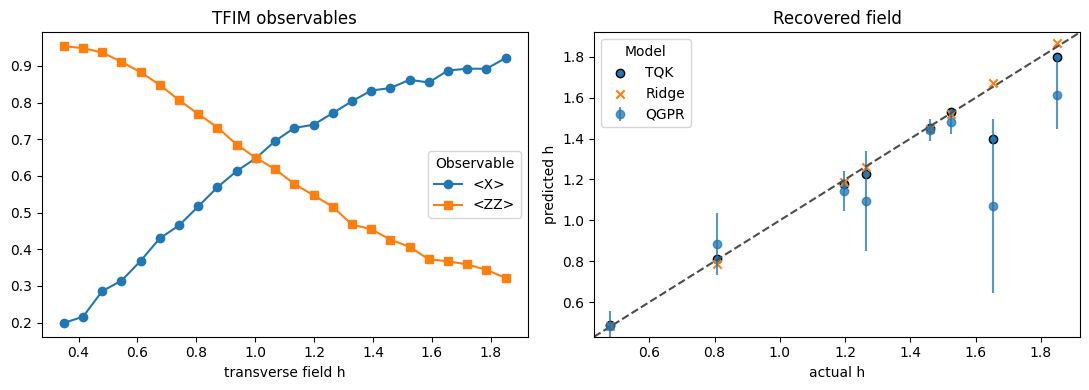

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = np.argsort(h_values)
axes[0].plot(h_values[order], features[order, 1], "o-", label="<X>")
axes[0].plot(h_values[order], features[order, 2], "s-", label="<ZZ>")
axes[0].set_title("TFIM observables")
axes[0].set_xlabel("transverse field h")
axes[0].legend(title="Observable")

low = min(h_test.min(), tqk_h_pred.min(), gpr_h_pred.min(), ridge_h_pred.min()) - 0.05
high = max(h_test.max(), tqk_h_pred.max(), gpr_h_pred.max(), ridge_h_pred.max()) + 0.05
axes[1].scatter(h_test, tqk_h_pred, label="TQK", edgecolor="black")
axes[1].errorbar(h_test, gpr_h_pred, yerr=gpr_h_std, fmt="o", label="QGPR", alpha=0.75)
axes[1].scatter(h_test, ridge_h_pred, marker="x", label="Ridge")
axes[1].plot([low, high], [low, high], "--", color="0.3")
axes[1].set_xlim(low, high)
axes[1].set_ylim(low, high)
axes[1].set_title("Recovered field")
axes[1].set_xlabel("actual h")
axes[1].set_ylabel("predicted h")
axes[1].legend(title="Model")
plt.tight_layout()
plt.show()


## Validation block

The final cell reports dataset metadata, metrics, sample predictions, and a `passed` flag.

In [6]:
validation = {
    "dataset": {
        "problem": "tfim_transverse_field_inference",
        "n_train": int(len(h_train)),
        "n_test": int(len(h_test)),
        "feature_count": int(x_train.shape[1]),
    },
    "results": results,
    "sample_predictions": [
        {"actual_h": float(a), "trainable_kernel_h": float(q), "quantum_gpr_h": float(g)}
        for a, q, g in zip(h_test[:6], tqk_h_pred[:6], gpr_h_pred[:6])
    ],
    "passed": bool(
        np.isfinite(tqk_h_pred).all()
        and np.isfinite(gpr_h_pred).all()
        and results["trainable_kernel_h_mae"] < 0.6
        and results["quantum_gpr_h_mae"] < 0.6
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:4])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------------+---------------------------------+
| Metric        | Value                           |
+---------------+---------------------------------+
| problem       | tfim_transverse_field_inference |
| n_train       | 16                              |
| n_test        | 8                               |
| feature_count | 4                               |
+---------------+---------------------------------+

Results
+-----------------------------+-----------+
| Metric                      | Value     |
+-----------------------------+-----------+
| trainable_kernel_h_mae      | 0.0483953 |
| quantum_gpr_h_mae           | 0.147426  |
| ridge_h_mae                 | 0.0103647 |
| trainable_kernel_alignment  | 0.466965  |
| trainable_kernel_loss_final | -0.466965 |
+-----------------------------+-----------+

Sample predictions
+----------+--------------------+---------------+
| actual_h | trainable_kernel_h | quantum_gpr_h |
+----------+--------------------+-------